# NEWS CLASSIFICATION PROJECT

# 1. Importing Libraries and Data Ingestion

## 1.1. Import Libraries

In [1]:
# --------------------------------------------------
# 1. Basic Libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import re

# --------------------------------------------------
# 2. Visualization
# --------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# --------------------------------------------------
# 3. NLP / Text Processing
# --------------------------------------------------
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# --------------------------------------------------
# 4. Machine Learning / Model Selection
# --------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# --------------------------------------------------
# 5. ML Models
# --------------------------------------------------
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# --------------------------------------------------
# 6. Metrics
# --------------------------------------------------
from sklearn.metrics import accuracy_score, classification_report


## 1.2. Downloads

In [ ]:
# NLTK Downloads (run once)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')  # optional if needed to resolve LookupError

## 1.3. Load and read Dataset

In [2]:
df = pd.read_json("News_Category_Dataset_v3.json", lines=True)


## 1.4. Make a copy of the dataframe




In [3]:
df_copy = df.copy()

# 2. Dataset Structure Check

In [4]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


NOTE: Combine 'headline' and 'short_description' into one column; seperate them by space.

In [5]:
df['combined_text'] = df['headline'] + ' ' + df['short_description']
df.head()

,link,headline,category,short_description,authors,date,combined_text
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li..."
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...


In [6]:
df.shape

(209527, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
 6   combined_text      209527 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 11.2+ MB


In [8]:
df.describe(include='object')

,link,headline,category,short_description,authors,combined_text
count,209527,209527,209527,209527,209527,209527
unique,209486,207996,42,187022,29169,209038
top,https://www.huffingtonpost.comhttp://stylelike...,Sunday Roundup,POLITICS,,,Watch The Top 9 YouTube Videos Of The Week If ...
freq,2,90,35602,19712,37418,46


# 3. Target Variable analysis

## 3.1. Verify number of unique categories

In [9]:
df['category'].nunique()

42

## 3.2. Category Distribution

This is to see if there is a class imbalance; which will inform performance metric choice.

In [10]:
category_counts = df['category'].value_counts()
category_counts.head(10)

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


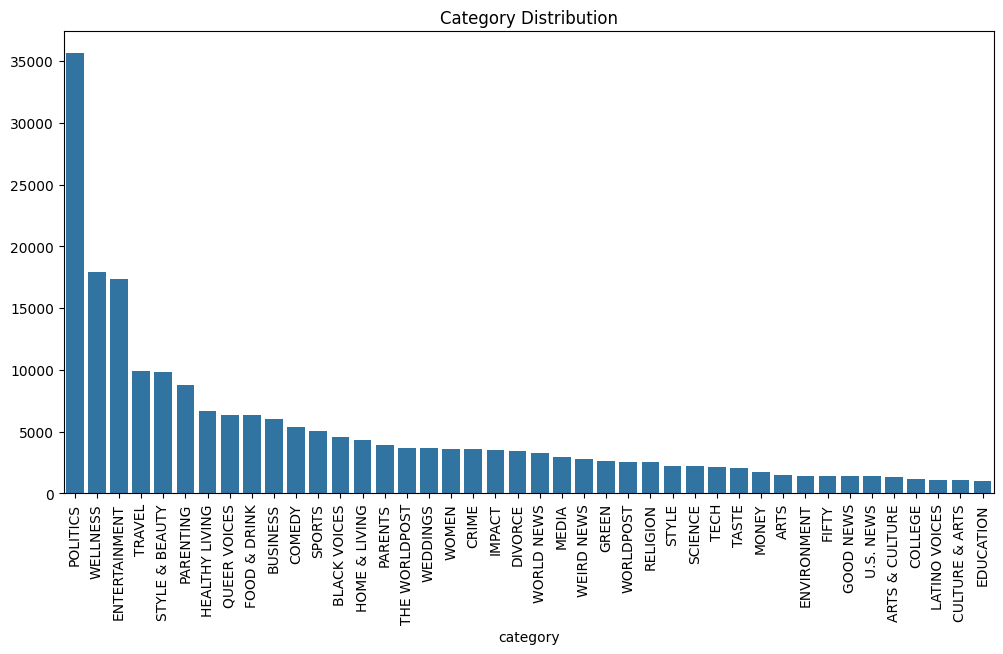

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=90)
plt.title("Category Distribution")
plt.show()


WE MUST FOCUS ON THESE CATEGORIES (Filter the dataset to): Business, Education, Entertainment, Technology, Sports.

/tmp/ipython-input-331/1691665394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_category_counts.index, y=filtered_category_counts.values, palette='viridis')


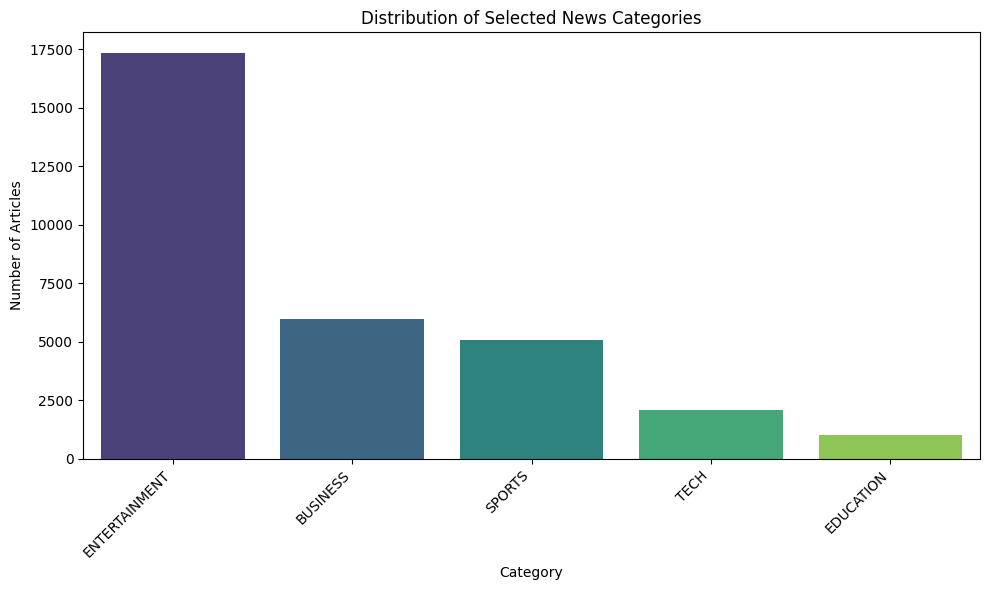

In [12]:
specific_categories = ['BUSINESS', 'EDUCATION', 'ENTERTAINMENT', 'TECH', 'SPORTS']
filtered_category_counts = df[df['category'].isin(specific_categories)]['category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=filtered_category_counts.index, y=filtered_category_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Selected News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

## 3.3. Clean Category Labels

In [13]:
df['category'] = df['category'].str.strip().str.upper()


# 4. Exploratory Data Analysis

## 4.1. Inspecting Valuable Text Columns

In [14]:
df['combined_text'].sample(5)


,combined_text
196521,Making a Difference: The World of Giving for Y...
125428,A Provence-Themed Dinner The real epitome of o...
129179,How to Pick a Movie That Says 'We're Not Havin...
78153,Lawmakers Have Tough Time Saying Their Candida...
89412,Braxton Miller At Wide Receiver Had LeBron Jam...


ADD WORD CLOUD TO SEE MOST POPULAR WORDS

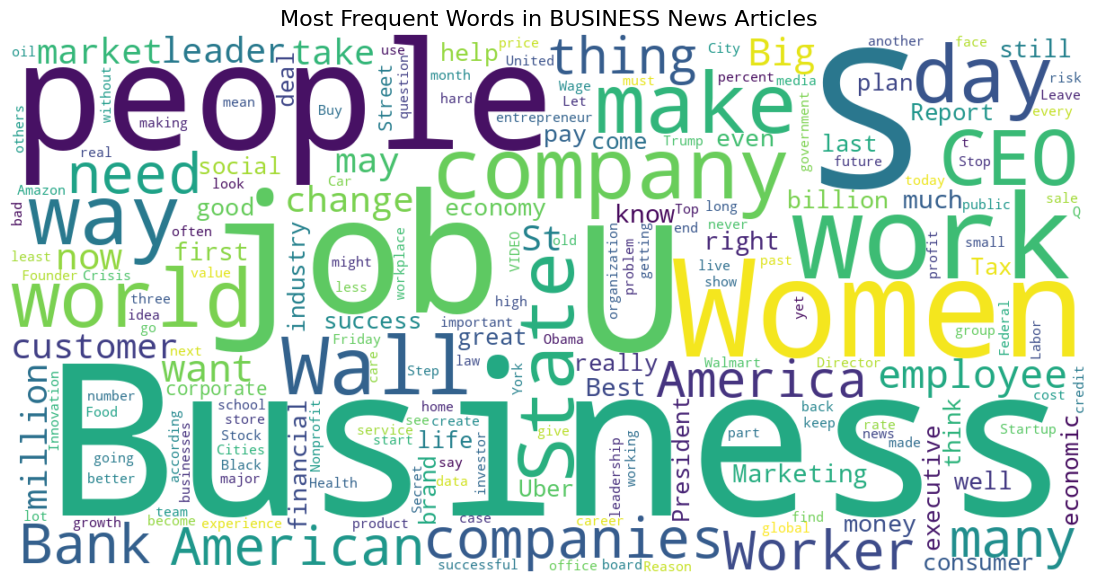

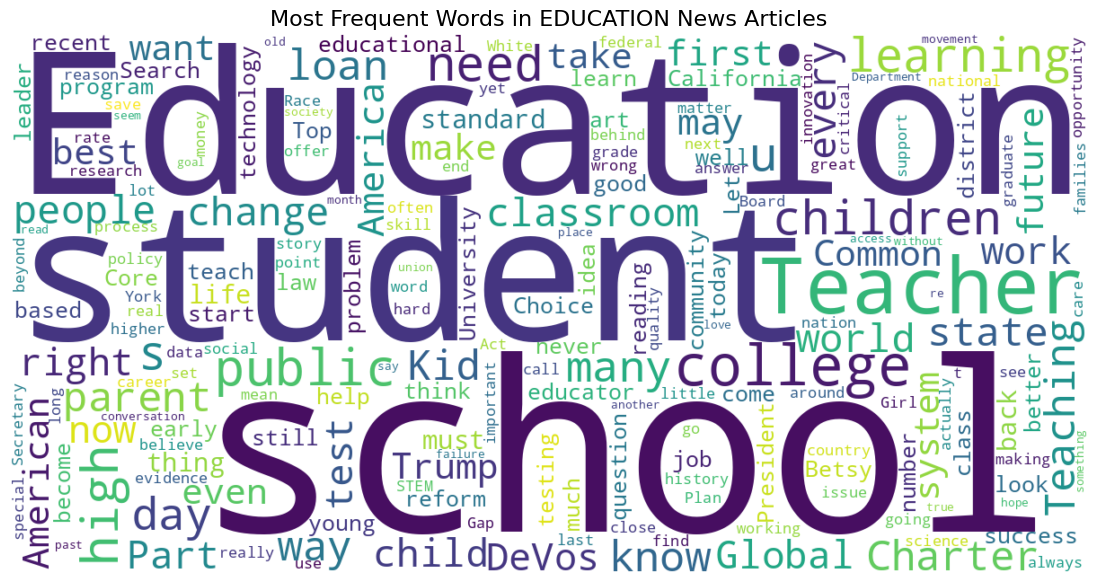

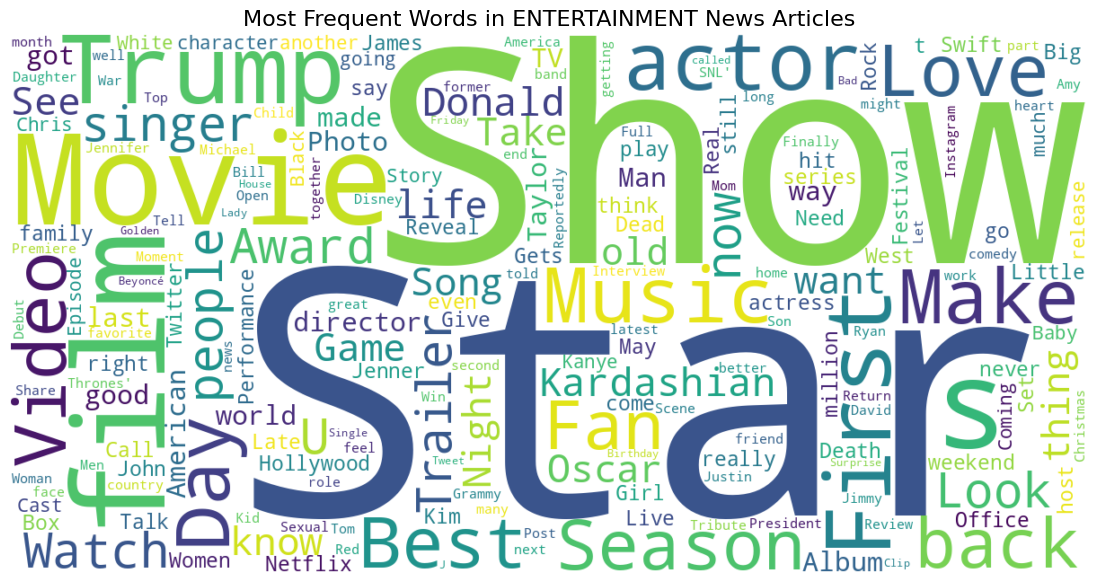

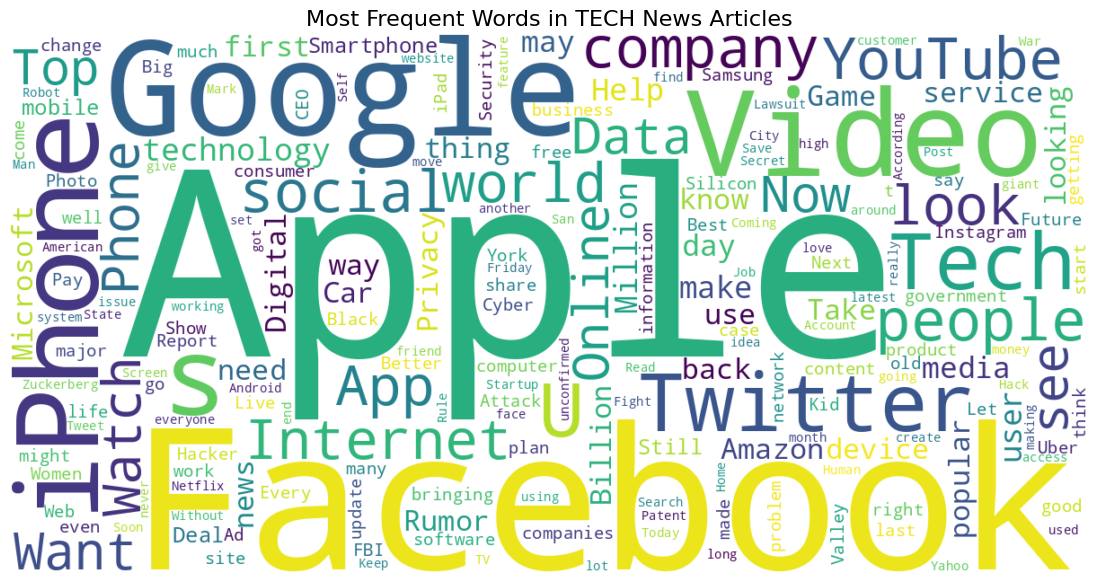

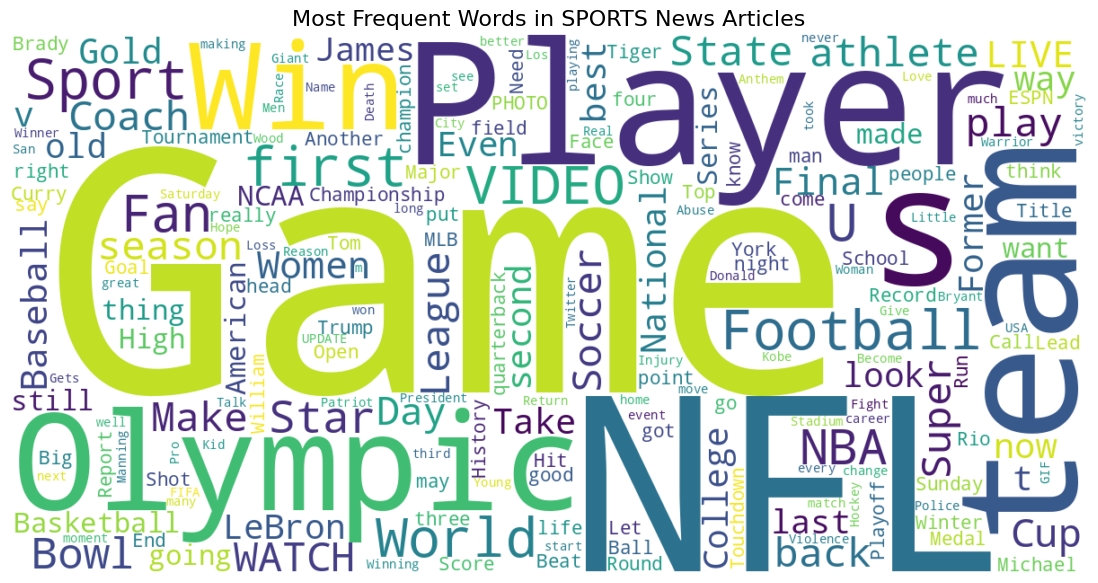

In [15]:
# --------------------------------------------------
# 1. Define categories of interest
# --------------------------------------------------
categories_of_interest = [
    'BUSINESS',
    'EDUCATION',
    'ENTERTAINMENT',
    'TECH',
    'SPORTS'
]

# --------------------------------------------------
# 2. Filter dataset for selected categories
# --------------------------------------------------
df_subset = df[df['category'].isin(categories_of_interest)]

# --------------------------------------------------
# 3. Define stopwords (default + domain-specific)
# --------------------------------------------------
stopwords = set(STOPWORDS)

custom_stopwords = {
    'said', 'says', 'will', 'new', 'one', 'two',
    'year', 'years', 'week', 'time'
}

stopwords = stopwords.union(custom_stopwords)

# --------------------------------------------------
# 4. Word cloud generation function
# --------------------------------------------------
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=stopwords,
        max_words=200,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# --------------------------------------------------
# 5. Generate word clouds for each category
# --------------------------------------------------
for category in categories_of_interest:
    category_text = " ".join(
        df_subset[df_subset['category'] == category]['combined_text'].dropna()
    )

    generate_wordcloud(
        category_text,
        f"Most Frequent Words in {category} News Articles"
    )




## 4.2. Missing Text Values

In [16]:
df[['combined_text', 'category']].isnull().sum()


,0
combined_text,0
category,0


# 5. Data Cleaning

## 5.1. Remove Duplicates

In [17]:
df.duplicated().sum()


np.int64(13)

In [18]:
df = df.drop_duplicates()


## 5.2. Drop Irrelevant Columns

In [19]:
df = df.drop(columns=['link'])


I dropped the 'link' column because it is not useful (noise).

## 5.3. Cleaning The Input Variables

In [20]:
# --------------------------------------------------
# Initialize NLP tools
# --------------------------------------------------
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Optional: add domain-specific stopwords (news-specific)
custom_stopwords = {
    'said', 'says', 'will', 'new', 'one', 'two',
    'year', 'years', 'week', 'time'
}

stop_words = stop_words.union(custom_stopwords)

# --------------------------------------------------
# Full text cleaning function
# --------------------------------------------------
def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation and extra whitespace
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 6. Stemming (optional but included as requested)
    tokens = [stemmer.stem(word) for word in tokens]

    # 7. Re-join tokens
    return " ".join(tokens)

# --------------------------------------------------
# Apply cleaning to combined_text column
# --------------------------------------------------
df['cleaned_text'] = df['combined_text'].apply(clean_text)

# Preview result
df[['combined_text', 'cleaned_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,combined_text,cleaned_text
0,Over 4 Million Americans Roll Up Sleeves For O...,4 million american roll sleev omicrontarget co...
1,"American Airlines Flyer Charged, Banned For Li...",american airlin flyer charg ban life punch fli...
2,23 Of The Funniest Tweets About Cats And Dogs ...,23 funniest tweet cat dog sept 1723 dog dont u...
3,The Funniest Tweets From Parents This Week (Se...,funniest tweet parent sept 1723 accident put g...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,woman call cop black birdwatch lose lawsuit ex...


# 7. Train and Test Split

When splitting the dataset, do we only split for our considered categories or we split the whole dataset as it is and the slection of categories part will come later on when training the model?

## Filter to 5 Categories

In [21]:
# Categories you want
selected_categories = [
    'BUSINESS',
    'EDUCATION',
    'ENTERTAINMENT',
    'TECH',
    'SPORTS'
]

# Keep only those categories
df_filtered = df[df['category'].isin(selected_categories)].copy()

print("Dataset size after filtering categories:", len(df_filtered))
print("Category distribution:\n")
print(df_filtered['category'].value_counts())


Dataset size after filtering categories: 31545
Category distribution:

category
ENTERTAINMENT    17362
BUSINESS          5992
SPORTS            5077
TECH              2100
EDUCATION         1014
Name: count, dtype: int64


In [22]:
# --------------------------------------------------
# 1. Make sure cleaned_text exists
# --------------------------------------------------
df_filtered['cleaned_text'] = df['cleaned_text'].fillna("").astype(str)

# --------------------------------------------------
# 2. REMOVE EMPTY ROWS BEFORE SPLITTING
# --------------------------------------------------
print("Rows before removing empty text:", len(df))

df_filtered = df_filtered[df_filtered['cleaned_text'].str.strip() != ""].reset_index(drop=True)

print("Rows after removing empty text:", len(df))


X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['cleaned_text'],
    df_filtered['category'],
    test_size=0.2,
    random_state=42,
    stratify=df_filtered['category']
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Rows before removing empty text: 209514
Rows after removing empty text: 209514
Train size: 25234
Test size: 6309


Next Steps:
* Vectorization (TFDI) /Embedding
* Label encoding
* Train 5 models and print performance metrics (base models) [Ensemble method]

# 8. Preprocessing

NOTE: It is important that you follow this order while preparing data:
1️⃣ Clean
2️⃣ Remove empty rows
3️⃣ Reset index
4️⃣ Split
5️⃣ Encode
6️⃣ Vectorize
7️⃣ Train

## 8.2. Label Encoding

In [25]:
# --------------------------------------------------
# Label Encoding the target
# --------------------------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding done!")
print("Number of classes:", len(le.classes_))


Label encoding done!
Number of classes: 5


## 8.2. Vectorization

NoTE:
* Remove this part; adding strings defeats the purpose and no need to save files as CSV files.
* SPLIT DIFFERENT PARTS OF CODES TO DIFFERENT CELLS

In [27]:
tfidf = TfidfVectorizer(
    #max_features=50000,
    #ngram_range=(1, 2) #REmove this part if not necessary, only work on it after understanding the model.
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF vectorization done!")
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


TF-IDF vectorization done!
Train shape: (25234, 26519)
Test shape: (6309, 26519)


## 8.3. Train Base Models

In [28]:
# --------------------------------------------------
# 1. Define all base models
# --------------------------------------------------
model_lr  = LogisticRegression(max_iter=1000, n_jobs=-1)
model_svm = LinearSVC()
model_nb  = MultinomialNB()
model_rf  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_sgd = SGDClassifier(loss="log_loss", random_state=42)
model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

models = {
    "Logistic Regression": model_lr,
    "Linear SVM": model_svm,
    "Naive Bayes": model_nb,
    "Random Forest": model_rf,
    "SGD Classifier": model_sgd,
    "XGBoost": model_xgb
}

# --------------------------------------------------
# 2. Train and evaluate each base model
# --------------------------------------------------
print("\n================ BASE MODELS PERFORMANCE ================\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train_enc)  # Train model

    y_pred = model.predict(X_test_tfidf)  # Predict on test set

    acc = accuracy_score(y_test_enc, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
    print("-" * 70)


================ BASE MODELS PERFORMANCE ================

Training Logistic Regression...

Logistic Regression Accuracy: 0.8743
               precision    recall  f1-score   support

     BUSINESS       0.84      0.82      0.83      1198
    EDUCATION       0.94      0.59      0.73       203
ENTERTAINMENT       0.87      0.98      0.92      3472
       SPORTS       0.93      0.78      0.85      1016
         TECH       0.84      0.55      0.67       420

     accuracy                           0.87      6309
    macro avg       0.88      0.74      0.80      6309
 weighted avg       0.88      0.87      0.87      6309

----------------------------------------------------------------------
Training Linear SVM...

Linear SVM Accuracy: 0.8938
               precision    recall  f1-score   support

     BUSINESS       0.85      0.83      0.84      1198
    EDUCATION       0.86      0.70      0.77       203
ENTERTAINMENT       0.92      0.97      0.94      3472
       SPORTS       0.90    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.8241
               precision    recall  f1-score   support

     BUSINESS       0.86      0.63      0.73      1198
    EDUCATION       0.81      0.73      0.77       203
ENTERTAINMENT       0.80      0.97      0.88      3472
       SPORTS       0.92      0.67      0.78      1016
         TECH       0.83      0.56      0.67       420

     accuracy                           0.82      6309
    macro avg       0.84      0.71      0.76      6309
 weighted avg       0.83      0.82      0.82      6309

----------------------------------------------------------------------


Code clean up!!

CHECK OUT: Pipeline

RESEARCH: HOW TO GET RID OF OVERFITTING

ADD TRAIN MODEL: XGBoost

Notes:
* Check how to interprete a classification model (what each metric tells us)
* What is overfitting and underfitting
* What is oversampling and undersampling
* Bias and variance in machine learning (Trade-off)
* What are models' hyperparameters (versus parameters) and examples


## 8.4. Ensemble Model

In [ ]:
# --------------------------------------------------
# 6. Build Ensemble (Voting Classifier)
# --------------------------------------------------
"""
ensemble = VotingClassifier(
    estimators=[
        ("lr", model_lr),
        ("svm", model_svm),
        ("nb", model_nb),
        ("rf", model_rf),
        ("sgd", model_sgd)
    ],
    voting="hard"  # majority vote
)

print("\n================ ENSEMBLE MODEL PERFORMANCE ================\n")

ensemble.fit(X_train_tfidf, y_train_enc)
y_pred_ens = ensemble.predict(X_test_tfidf)

acc_ens = accuracy_score(y_test_enc, y_pred_ens)
print(f"Ensemble Accuracy: {acc_ens:.4f}")
print(classification_report(y_test_enc, y_pred_ens, target_names=le.classes_))
"""